# Star Detection and Cluster Density Analysis

## Overview
This notebook demonstrates an astronomical data analysis problem using Python and relevant techniques.

## Objective
- Detect stars
- Compute density
- Classify clusters


Total Stars: 2457
Average Nearest Distance: 10.477378912216484
Cluster Density: 0.09544371816447465
Classification: Dense Cluster


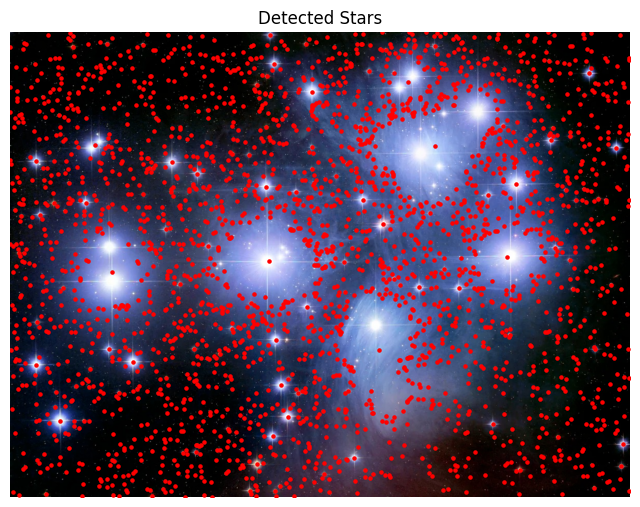

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

# Load image
img = cv2.imread("stars.jpg")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Threshold
_, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

# Connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)

centroids = centroids[1:]  # remove background

num_stars = len(centroids)

# Pairwise distances
dist_matrix = distance.cdist(centroids, centroids)

np.fill_diagonal(dist_matrix, np.inf)

nearest = np.min(dist_matrix, axis=1)

avg_nearest = np.mean(nearest)

# Density from distance
density = 1 / avg_nearest

# Classification
if avg_nearest < 20:
    classification = "Dense Cluster"
else:
    classification = "Sparse Cluster"

print("Total Stars:", num_stars)
print("Average Nearest Distance:", avg_nearest)
print("Cluster Density:", density)
print("Classification:", classification)

# Plot stars
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.scatter(centroids[:,0], centroids[:,1], s=5, color='red')
plt.title("Detected Stars")
plt.axis("off")
plt.show()

## Conclusion
The analysis demonstrates application of Python-based techniques on astronomical data.

## Key Techniques Used
- OpenCV
- Connected Components
- Distance Metrics
